# Project Code
All code used in the project are listed in this Jupyter notebook

1. Import necessary librairies not needed by NanoGPT and prepare the data for the training

In [2]:
import os
import re
os.system('python data/shakespeare_char/prepare.py')

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


0

2. Create the configuration file with the baseline option
3. Create the parameters to be changed and create new config files with these changes

In [ ]:
#writing the file with all model and training parameters, NOTE: set to gpu with linux
file_content_standard = '# Baseline configuration \nout_dir = \'out-shakespeare-baseline\' \neval_interval = 250 \neval_iters = 200 \nlog_interval = 10 \nalways_save_checkpoint = False \nwandb_log = False \nwandb_project = \'nanoGPT-assignment\' \nwandb_run_name = \'baseline\' \ndataset = \'shakespeare_char\' \ngradient_accumulation_steps = 1 \nbatch_size = 64 \nblock_size = 256 \nn_layer = 6 \nn_head = 6 \nn_embd = 384 \ndropout = 0.2 \nlearning_rate = 1e-3 \nmax_iters = 5000 \nlr_decay_iters = 5000 \nmin_lr = 1e-4 \nbeta2 = 0.99 \nwarmup_iters = 100 \nweight_decay = 1e-1 \ndevice = \'cpu\' # change to \'cuda\' if you have a GPU \ncompile = False # set True only on Linux with GPU'
file_content_linux_gpu = '# Baseline configuration \nout_dir = \'out-shakespeare-baseline\' \neval_interval = 250 \neval_iters = 200 \nlog_interval = 10 \nalways_save_checkpoint = False \nwandb_log = False \nwandb_project = \'nanoGPT-assignment\' \nwandb_run_name = \'baseline\' \ndataset = \'shakespeare_char\' \ngradient_accumulation_steps = 1 \nbatch_size = 64 \nblock_size = 256 \nn_layer = 6 \nn_head = 6 \nn_embd = 384 \ndropout = 0.2 \nlearning_rate = 1e-3 \nmax_iters = 5000 \nlr_decay_iters = 5000 \nmin_lr = 1e-4 \nbeta2 = 0.99 \nwarmup_iters = 100 \nweight_decay = 1e-1 \ndevice = \'cuda\' # change to \'cuda\' if you have a GPU \ncompile = True # set True only on Linux with GPU'
file_content = file_content_linux_gpu
with open('config/training_shakespeare_char_baseline.py', 'w') as file:
    file.write(file_content)

file.close()

experiments_parameters = [('block_size', 64), ('dropout', 0.0), ('n_layer', 2), ('n_layer', 8)]

for parameter in experiments_parameters:
    new_file_content = re.sub(rf'({parameter[0]} = ).*', rf'\g<1>{parameter[1]}', file_content)
    
    new_file_content = re.sub(r'(out_dir = )\S+', rf"\g<1>'out-shakespeare-{parameter[0]}{parameter[1]}'", new_file_content)
    with open(f'config/training_shakespeare_char_{parameter[0]}{parameter[1]}.py', 'w') as file:
        file.write(new_file_content)
    file.close()

4. Train the baseline model while recording time and activity of NanoGPT

In [12]:

os.system('python train.py config/training_shakespeare_char_baseline.py | ts | tee logs/baseline.log')
#with open('config/training_shakespeare_char_baseline.py')

Apr 18 13:02:18 Overriding config with config/training_shakespeare_char_baseline.py:
Apr 18 13:02:18 # Baseline configuration 
Apr 18 13:02:18 out_dir = 'out-shakespeare-baseline' 
Apr 18 13:02:18 eval_interval = 250 
Apr 18 13:02:18 eval_iters = 200 
Apr 18 13:02:18 log_interval = 10 
Apr 18 13:02:18 always_save_checkpoint = False 
Apr 18 13:02:18 wandb_log = False 
Apr 18 13:02:18 wandb_project = 'nanoGPT-assignment' 
Apr 18 13:02:18 wandb_run_name = 'baseline' 
Apr 18 13:02:18 dataset = 'shakespeare_char' 
Apr 18 13:02:18 gradient_accumulation_steps = 1 
Apr 18 13:02:18 batch_size = 64 
Apr 18 13:02:18 block_size = 256 
Apr 18 13:02:18 n_layer = 6 
Apr 18 13:02:18 n_head = 6 
Apr 18 13:02:18 n_embd = 384 
Apr 18 13:02:18 dropout = 0.2 
Apr 18 13:02:18 learning_rate = 1e-3 
Apr 18 13:02:18 max_iters = 5000 
Apr 18 13:02:18 lr_decay_iters = 5000 
Apr 18 13:02:18 min_lr = 1e-4 
Apr 18 13:02:18 beta2 = 0.99 
Apr 18 13:02:18 warmup_iters = 100 
Apr 18 13:02:18 weight_decay = 1e-1 
Apr 18

/home/lucask/Documents/NanoGPT/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Apr 18 13:02:19 using fused AdamW: True
Apr 18 13:02:19 compiling the model... (takes a ~minute)


W0418 13:02:25.175000 51288 .venv/lib/python3.14/site-packages/torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(


Apr 18 13:05:10 step 0: train loss 4.2874, val loss 4.2823


/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(


Apr 18 13:05:17 iter 0: loss 4.2713, time 176698.34ms, mfu -100.00%
Apr 18 13:05:33 iter 10: loss 3.1479, time 1610.24ms, mfu 0.23%
Apr 18 13:05:38 iter 20: loss 2.7326, time 578.47ms, mfu 0.27%
Apr 18 13:05:44 iter 30: loss 2.6203, time 581.20ms, mfu 0.31%
Apr 18 13:05:50 iter 40: loss 2.5788, time 579.54ms, mfu 0.34%
Apr 18 13:05:56 iter 50: loss 2.5263, time 580.21ms, mfu 0.37%
Apr 18 13:06:02 iter 60: loss 2.5114, time 579.74ms, mfu 0.40%
Apr 18 13:06:07 iter 70: loss 2.4931, time 583.28ms, mfu 0.42%
Apr 18 13:06:13 iter 80: loss 2.4944, time 583.09ms, mfu 0.45%
Apr 18 13:06:19 iter 90: loss 2.4629, time 583.88ms, mfu 0.46%
Apr 18 13:06:25 iter 100: loss 2.4584, time 584.84ms, mfu 0.48%
Apr 18 13:06:31 iter 110: loss 2.4518, time 583.42ms, mfu 0.50%
Apr 18 13:06:37 iter 120: loss 2.4313, time 586.57ms, mfu 0.51%
Apr 18 13:06:42 iter 130: loss 2.4162, time 586.93ms, mfu 0.52%
Apr 18 13:06:48 iter 140: loss 2.3959, time 588.28ms, mfu 0.53%
Apr 18 13:06:54 iter 150: loss 2.4000, time 

0

Generate samples from the baseline model (still work-in-progress)

In [9]:
os.system('python sample.py --out_dir=out-shakespeare-n_layer8 \
 --device=cuda --num_samples=3 --max_new_tokens=500')

Overriding: out_dir = out-shakespeare-n_layer8
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 500
number of parameters: 14.19M
Loading meta from data/shakespeare_char/meta.pkl...

And they brides.

STANLEY:
He mades that you was the damb'd?

TRUMIO:
My partuous the trace that a enfriend of himself.

CORIOLANUS:
My for the couls would beged in ensmore mine is the overt,
Here me now on than of like dise of the recure by pray;
And the tyrant to sent my fair the quich sworld that
And in on him piides the more rive with in his soung him.
Here kind thrust for the ristress thre in exection.

PETER:
I am that is be still is wards.
When if the voicinst of rate
Hir his changer vowi
---------------

Men partion marry in the hasteds of a change.

DUKE OF YORK:
Are him; sir; I have not us body.

TYBRLANNE:
I should soul. 
LEONTES:
Hape the sover pared me oven the parse
Which in meen their so upon sixt fear.
As not come, for his heart, if
My for more the want bear

0

5. Train all variant models with logs

In [13]:
for parameter in experiments_parameters:
    os.system(f'python train.py config/training_shakespeare_char_{parameter[0]}{parameter[1]}.py | ts | tee logs/{parameter[0]}{parameter[1]}.log')

Apr 19 15:21:55 Overriding config with config/training_shakespeare_char_dropout0.0.py:
Apr 19 15:21:55 # Baseline configuration 
Apr 19 15:21:55 out_dir = 'out-shakespeare-dropout0.0' 
Apr 19 15:21:55 eval_interval = 250 
Apr 19 15:21:55 eval_iters = 200 
Apr 19 15:21:55 log_interval = 10 
Apr 19 15:21:55 always_save_checkpoint = False 
Apr 19 15:21:55 wandb_log = False 
Apr 19 15:21:55 wandb_project = 'nanoGPT-assignment' 
Apr 19 15:21:55 wandb_run_name = 'baseline' 
Apr 19 15:21:55 dataset = 'shakespeare_char' 
Apr 19 15:21:55 gradient_accumulation_steps = 1 
Apr 19 15:21:55 batch_size = 64 
Apr 19 15:21:55 block_size = 256 
Apr 19 15:21:55 n_layer = 6 
Apr 19 15:21:55 n_head = 6 
Apr 19 15:21:55 n_embd = 384 
Apr 19 15:21:55 dropout = 0.0
Apr 19 15:21:55 learning_rate = 1e-3 
Apr 19 15:21:55 max_iters = 5000 
Apr 19 15:21:55 lr_decay_iters = 5000 
Apr 19 15:21:55 min_lr = 1e-4 
Apr 19 15:21:55 beta2 = 0.99 
Apr 19 15:21:55 warmup_iters = 100 
Apr 19 15:21:55 weight_decay = 1e-1 
Apr

/home/lucask/Documents/NanoGPT/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Apr 19 15:21:57 using fused AdamW: True
Apr 19 15:21:57 compiling the model... (takes a ~minute)


W0419 15:22:05.287000 19957 .venv/lib/python3.14/site-packages/torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(


Apr 19 15:23:21 step 0: train loss 4.2874, val loss 4.2823


/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/lucask/Documents/NanoGPT/nanoGPT/.venv/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:2941: UserWarning: NVIDIA GeForce GTX 1660 Ti with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(


Apr 19 15:23:26 iter 0: loss 4.2864, time 86996.27ms, mfu -100.00%
Apr 19 15:23:31 iter 10: loss 3.0334, time 579.55ms, mfu 0.64%
Apr 19 15:23:37 iter 20: loss 2.6592, time 579.47ms, mfu 0.64%
Apr 19 15:23:43 iter 30: loss 2.5844, time 580.64ms, mfu 0.64%
Apr 19 15:23:49 iter 40: loss 2.5337, time 580.92ms, mfu 0.64%
Apr 19 15:23:55 iter 50: loss 2.4943, time 580.80ms, mfu 0.64%
Apr 19 15:24:00 iter 60: loss 2.4760, time 582.72ms, mfu 0.64%
Apr 19 15:24:06 iter 70: loss 2.4579, time 581.10ms, mfu 0.64%
Apr 19 15:24:12 iter 80: loss 2.4656, time 582.62ms, mfu 0.64%
Apr 19 15:24:18 iter 90: loss 2.4294, time 580.69ms, mfu 0.64%
Apr 19 15:24:24 iter 100: loss 2.4083, time 581.90ms, mfu 0.64%
Apr 19 15:24:30 iter 110: loss 2.3971, time 581.93ms, mfu 0.64%
Apr 19 15:24:35 iter 120: loss 2.3572, time 582.59ms, mfu 0.64%
Apr 19 15:24:41 iter 130: loss 2.3127, time 582.28ms, mfu 0.64%
Apr 19 15:24:47 iter 140: loss 2.2861, time 583.46ms, mfu 0.64%
Apr 19 15:24:53 iter 150: loss 2.2518, time 58

6. Retrieve the results in a dataset for future statistics

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Parse the log file and build a matrix
results = []  # Each row: [experiment, step, train_loss, val_loss]
experiment_list = ['baseline', 'block size = 64', 'dropout = 0.0', 'layers = 2', 'layers = 8']
count = 0

for logfile in os.listdir('final logs'):
    results.append([])
    with open(f'final logs/{logfile}', 'r') as f:
        for line in f:
            match = re.search(r'step (\d+): train loss (\d+\.\d+), val loss (\d+\.\d+)', line)
            if match:
                step = int(match.group(1))
                train_loss = float(match.group(2))
                val_loss = float(match.group(3))
                results[count].append([step, train_loss, val_loss])

    f.close()
    count += 1

results = np.array(results)

7. Plot the Training Loss during the training of all models

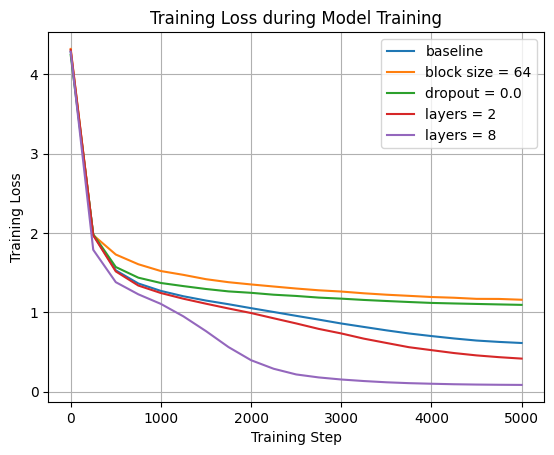

In [32]:
for experiment_num in range(len(results)):
    experiment = results[experiment_num]
    plt.plot(experiment.T[0], experiment.T[1], label=experiment_list[experiment_num])

plt.title('Training Loss during Model Training')
plt.xlabel('Training Step')
plt.ylabel('Training Loss')
plt.legend()
plt.grid()
plt.show()

8. Plot the Validation Loss during the training of all models

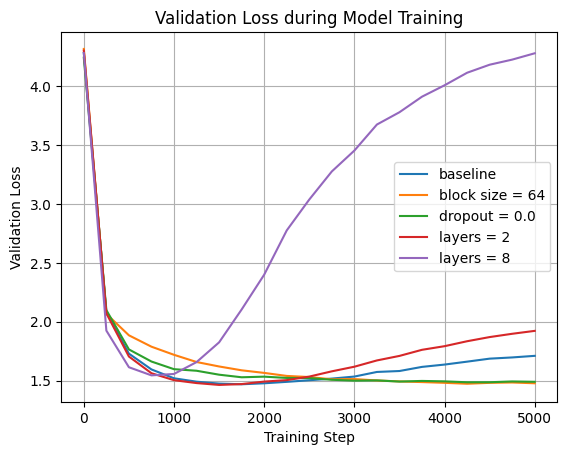

In [34]:
for experiment_num in range(len(results)):
    experiment = results[experiment_num]
    plt.plot(experiment.T[0], experiment.T[2], label=experiment_list[experiment_num])

plt.title('Validation Loss during Model Training')
plt.xlabel('Training Step')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()